In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading xLSTM 7B...")
xlstm_config = AutoConfig.from_pretrained("NX-AI/xLSTM-7b")
xlstm_config.step_kernel = "native"
xlstm_config.chunkwise_kernel = "chunkwise--native_autograd"
xlstm_config.sequence_kernel = "native_sequence__native"

model = AutoModelForCausalLM.from_pretrained("NX-AI/xLSTM-7b", config=xlstm_config, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained("NX-AI/xLSTM-7b")
tokenizer.pad_token = tokenizer.eos_token

d:\A_Facultate\Diseration\code\Dissertation-code\logit_lens\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading xLSTM 7B...


Loading weights: 100%|██████████| 483/483 [00:37<00:00, 13.03it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


In [52]:
# Your prompt
prompt = "Well, Prince, so Genoa and Lucca are now just family estates of the Buonapartes. But I warn you, if you don't tell me that this means war, if you still try to defend the infamies and horrors perpetrated by that Antichrist. I really believe he is Antichrist. I will have nothing more to do with you and you are no longer my friend, no longer my faithful slave, as you call yourself! But how do you do? I see I have frightened you! Sit down and tell me all the news. It was in July, 1805, and the speaker was the well known Anna Pavlovna Scherer, maid of honor and favorite of the Empress Marya Fedorovna. With these words she greeted Prince Vasili Kuragin, a man of high rank and importance, who was the first to arrive at her reception."

# prompt = "The quick brown fox jumps over the lazy dog."
# Tokenize and send to the same device as the model
input_ids = tokenizer(prompt, return_tensors="pt")['input_ids'].to(model.device)

In [53]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers.models.xlstm.modeling_xlstm import soft_cap


# ---------------------------------------------------------------------------
# 1. Hook every mLSTM layer to capture its input x_mlstm
# ---------------------------------------------------------------------------
xs = {}   # layer_idx -> tensor (B, T, D)
hooks = []
for ell, block in enumerate(model.backbone.blocks):
    def pre_hook(module, args, kwargs, ell=ell):
        x = args[0] if args else kwargs["x"]
        xs[ell] = x.detach()
    hooks.append(block.mlstm_layer.register_forward_pre_hook(pre_hook, with_kwargs=True))

with torch.no_grad():
    model(input_ids=input_ids)

for h in hooks:
    h.remove()


# ---------------------------------------------------------------------------
# 2. Per-layer: recompute i_bar, f_bar from x  (paper-faithful, stabilized)
# ---------------------------------------------------------------------------
@torch.no_grad()
def gates_for_layer(layer_idx):
    layer = model.backbone.blocks[layer_idx].mlstm_layer
    cfg   = layer.config
    H, cap = cfg.num_heads, cfg.gate_soft_cap

    x = xs[layer_idx].float()                        # (B, T, D)
    B, T, _ = x.shape

    # gate pre-activations (single or fused weight mode)
    if cfg.weight_mode == "single":
        i_hat = soft_cap(layer.igate_preact(x), cap)
        f_hat = soft_cap(layer.fgate_preact(x), cap)
    else:
        ifp = soft_cap(layer.ifgate_preact(x), cap)
        i_hat, f_hat = torch.tensor_split(ifp, (H,), dim=-1)
    i_hat = i_hat.transpose(1, 2).float()             # (B, H, T)
    f_hat = f_hat.transpose(1, 2).float()

    # roll the m-state to get stabilized gates exactly like the model does
    m   = torch.zeros(B, H, 1, device=x.device)
    ibar = torch.empty(B, H, T, device=x.device)
    fbar = torch.empty(B, H, T, device=x.device)
    for t in range(T):
        i_t   = i_hat[:, :, t:t+1]
        f_t   = f_hat[:, :, t:t+1]
        f_log = F.logsigmoid(f_t)
        m_new = torch.maximum(f_log + m, i_t)
        ibar[:, :, t] = torch.exp(i_t   - m_new).squeeze(-1)
        fbar[:, :, t] = torch.exp(f_log + m - m_new).squeeze(-1)
        m = m_new
    return ibar, fbar                                 # each (B, H, T)


L = len(model.backbone.blocks)
ibar_all, fbar_all = [], []
for ell in range(L):
    i_b, f_b = gates_for_layer(ell)
    ibar_all.append(i_b); fbar_all.append(f_b)
ibar_all = torch.stack(ibar_all, dim=0)               # (L, B, H, T)
fbar_all = torch.stack(fbar_all, dim=0)


# ---------------------------------------------------------------------------
# 3. Mean across heads and layers -> one value per token
# ---------------------------------------------------------------------------
b = 0
ibar_token = ibar_all[:, b].mean(dim=(0, 1)).cpu()    # (T,)
fbar_token = fbar_all[:, b].mean(dim=(0, 1)).cpu()    # (T,)

tokens = tokenizer.convert_ids_to_tokens(input_ids[b].tolist())
tokens = [t.replace("Ġ", " ").replace("▁", " ") for t in tokens]
T = len(tokens)

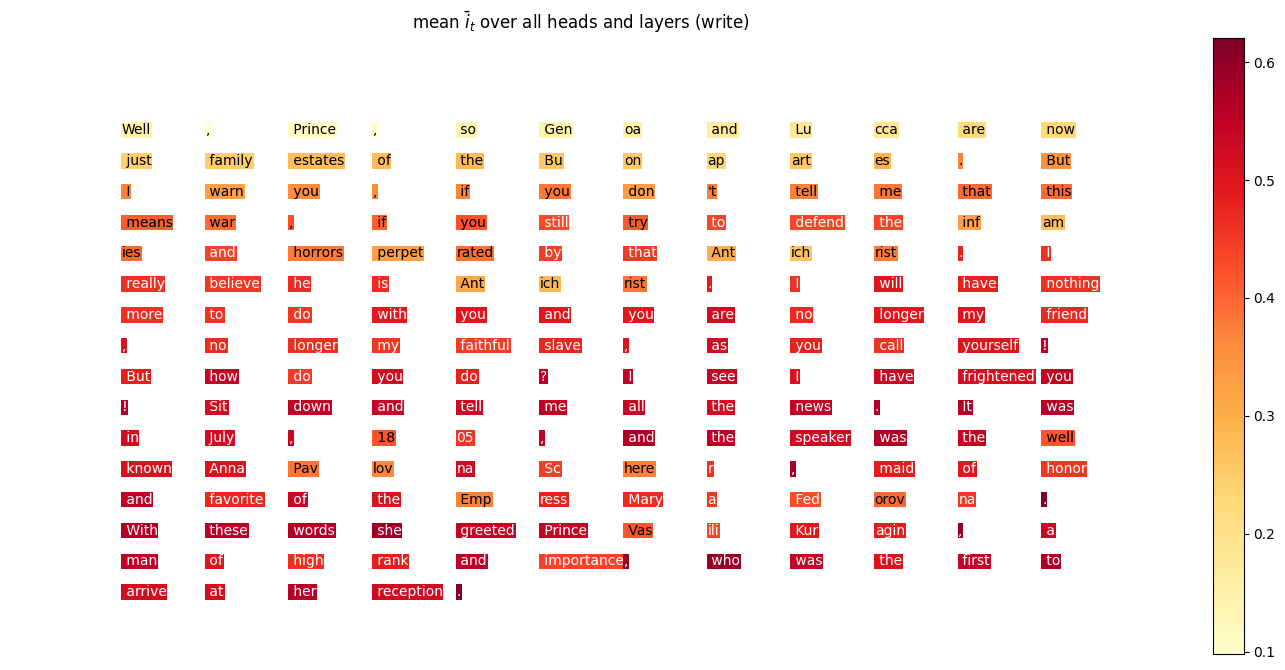

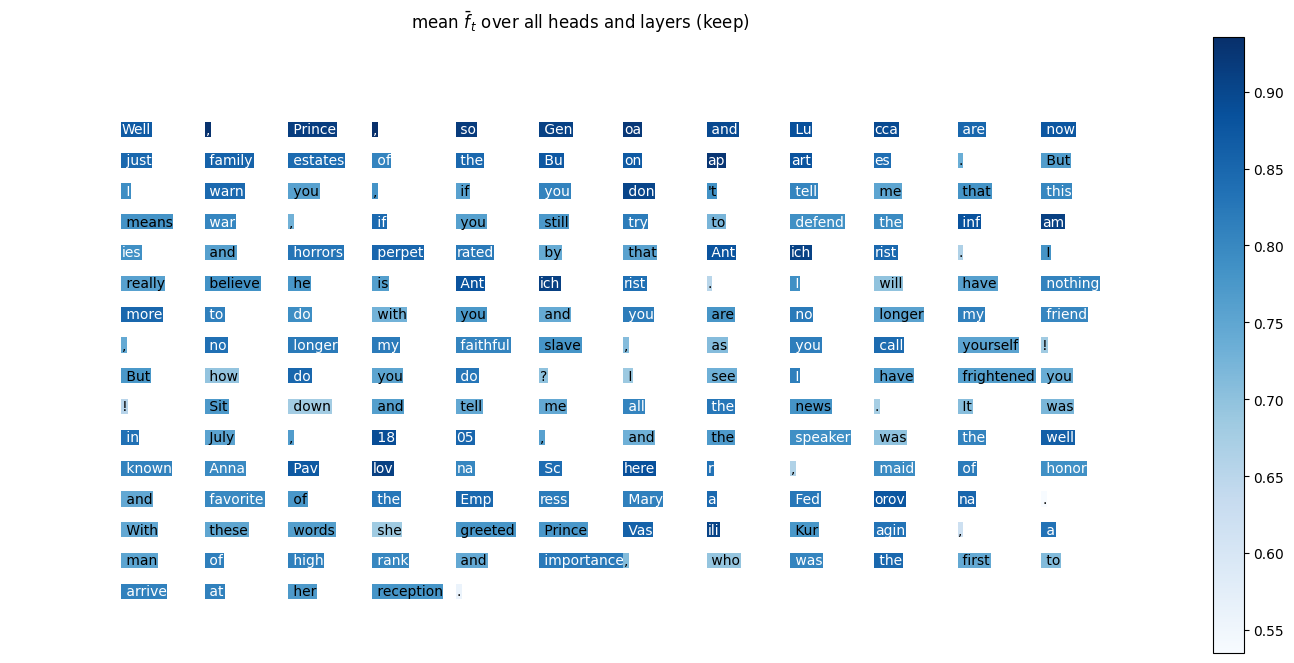

In [54]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def colored_text(values, tokens, cmap_name, title,
                 vmin=None, vmax=None,
                 tokens_per_row=20, fig_width=16):
    vmin = float(values.min()) if vmin is None else vmin
    vmax = float(values.max()) if vmax is None else vmax
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap(cmap_name)

    n = len(tokens)
    n_rows = (n + tokens_per_row - 1) // tokens_per_row

    fig, ax = plt.subplots(figsize=(fig_width, n_rows / 2))
    ax.set_axis_off()
    ax.set_title(title)

    x_start, x_end = 0.01, 0.89
    row_height = 0.05

    for i, (tok, val) in enumerate(zip(tokens, values)):
        row = i // tokens_per_row
        col = i % tokens_per_row
        x = x_start + (x_end - x_start) * (col / tokens_per_row + 0.1)
        y = 1 - (row + 3) * row_height
        rgba = cmap(norm(val))
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "white" if luminance < 0.5 else "black"
        
        ax.text(x, y, tok, transform=ax.transAxes,
                va="center", color=text_color,
                bbox=dict(facecolor=rgba, edgecolor="none", pad=0.5))

    cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap),
                        ax=ax, fraction=0.03)
    plt.show()


colored_text(ibar_token, tokens, "YlOrRd",
             r"mean $\bar i_t$ over all heads and layers (write)",
            tokens_per_row=12)

colored_text(fbar_token, tokens, "Blues",
             r"mean $\bar f_t$ over all heads and layers (keep)",
          tokens_per_row=12)